# Result Analysis

This notebook contains the analysis and visualization of voting prediction results.
Separated from the experiment running for better organization.

In [1]:
# Core imports
import os
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload

# Local imports
import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult
import Models_Utils
import Data_Utils

In [4]:
# Configuration
LANGUAGE = SoD_Utils.LANGUAGE_CZ
PARTIES = Data_Utils.PARTY_COLUMNS_2021

# Load original data for claimed results comparison
data_path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)

# Vectorized extraction without Python loop
claimed_votes = df[['Q21']].rename(columns={'Q21': 'voted_party'})
print(f"Loaded survey data: {len(claimed_votes)} respondents")

actual_results_df = Data_Utils.load_actual_results()
actual_results_country = actual_results_df[actual_results_df["region"]=="Česko"].iloc[0]

Loaded survey data: 3880 respondents
Loaded actual results: region                                               Česko
Voted                                               0.6543
Not Voted                                           0.3457
ANO 2011                                            0.2712
Koalice Spolu (ODS, TOP 09, KDU-ČSL)                0.2779
Koalice PIRÁTI a STAROSTOVÉ                         0.1562
Komunistická strana Čech a Moravy (KSČM)             0.036
Svoboda a přímá demokracie – Tomio Okamura (SPD)    0.0956
Česká strana sociálně demokratická (ČSSD)           0.0465
Trikolóra, Svobodní a Soukromníci                   0.0276
Přísaha Roberta Šlachty                             0.0468
Jiná strana                                         0.0422
Name: 0, dtype: object


In [5]:
# Load voting results from saved files
# Modify the model name and file path as needed
MODEL = "gpt-4o"
voting_results = pd.read_csv(f"results/voting_results_n=3880_t=0_{MODEL}.csv")

print(f"Loaded voting results: {len(voting_results)} respondents")
print(f"Model: {MODEL}")

Loaded voting results: 3880 respondents
Model: gpt-4o
Temperature: 0


## Visualization

Generate comprehensive visualizations comparing predicted vs actual results.

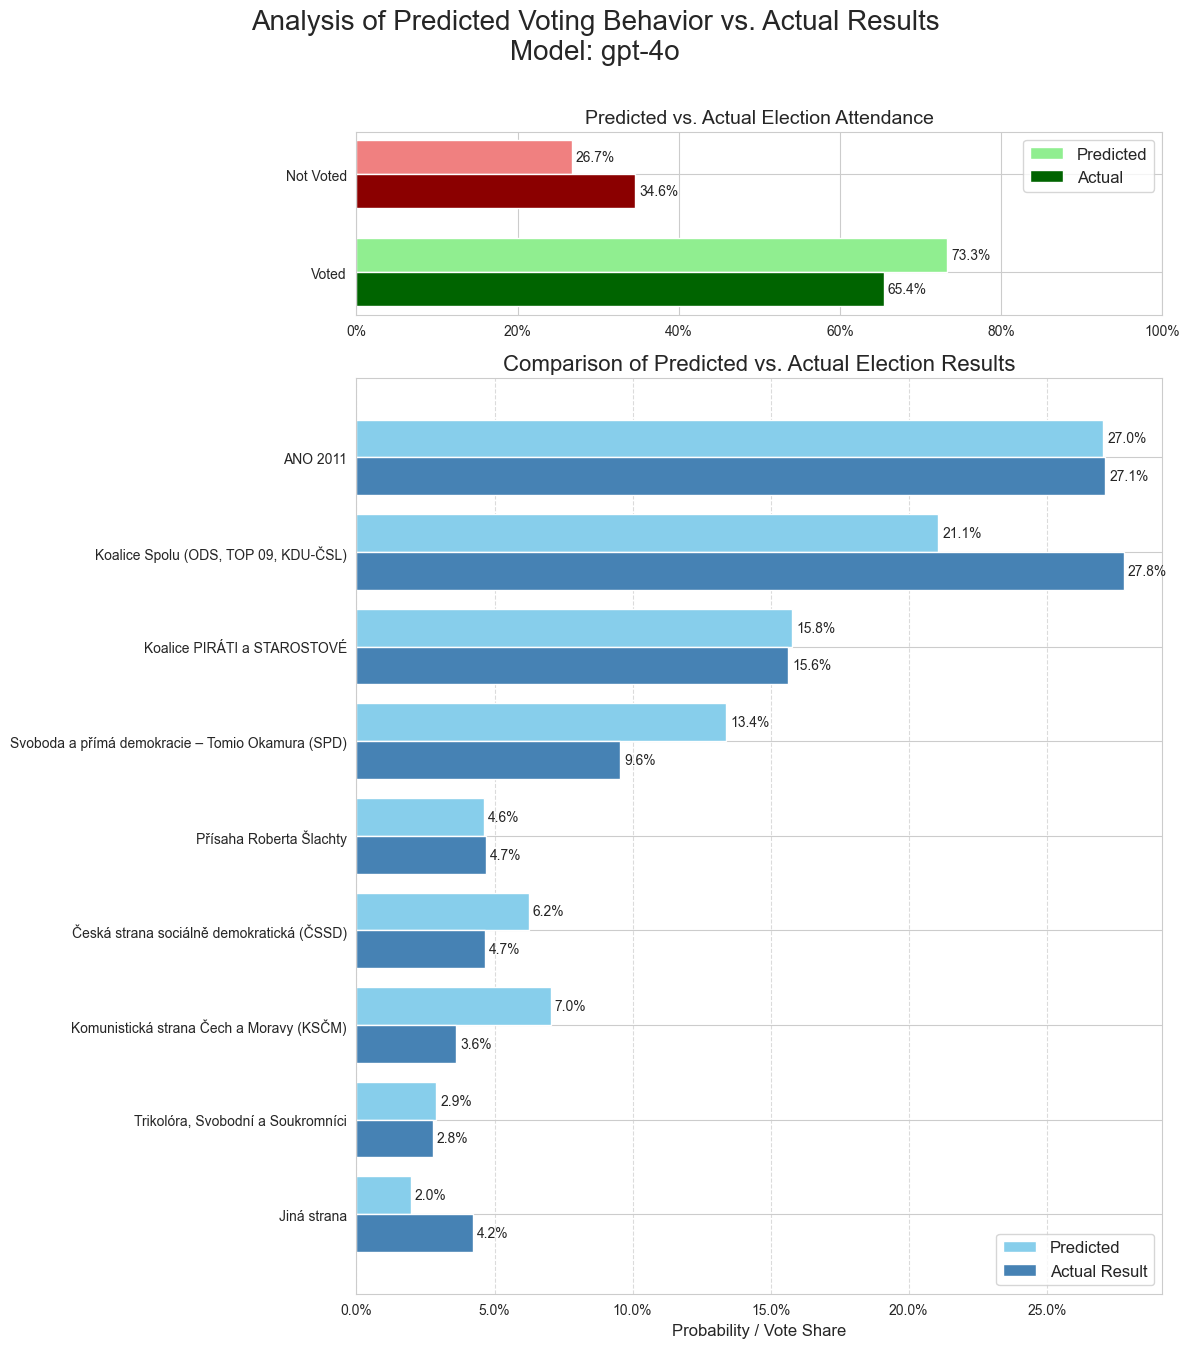

In [6]:
# Generate aggregated results and visualizations
predicted_results = Data_Utils.aggregate_results_from_df(voting_results)
_ = Visualization_Utils.visualize_comprehensive_results(
    predicted_results,
    actual_results_country,
    Data_Utils.PARTY_COLUMNS_2021,
    model_name=MODEL, actual_is_claimed=False
)

## Multi-Model Comparison

Compare results across different models.

In [11]:
# List of model names to compare
model_names = [
    "gpt-4.1-nano",
    "gpt-4o-mini",
    "gpt-4.1",
    "gpt-4o"
]

# Load all model results
voting_results_list = []
for model_name in model_names:
    try:
        voting_results_df = pd.read_csv(f"results/voting_results_n=3880_t=0_{model_name}.csv", index_col=0)
        voting_results_list.append(voting_results_df)
        print(f"✓ Loaded {model_name}: {len(voting_results_df)} respondents")
    except FileNotFoundError:
        print(f"✗ File not found for {model_name}")
        voting_results_list.append({})


✓ Loaded gpt-4.1-nano: 3880 respondents
✓ Loaded gpt-4o-mini: 3880 respondents
✓ Loaded gpt-4.1: 3880 respondents
✓ Loaded gpt-4o: 3880 respondents


Saved graph for gpt-4.1-nano
Saved graph for gpt-4o-mini
Saved graph for gpt-4.1
Saved graph for gpt-4o


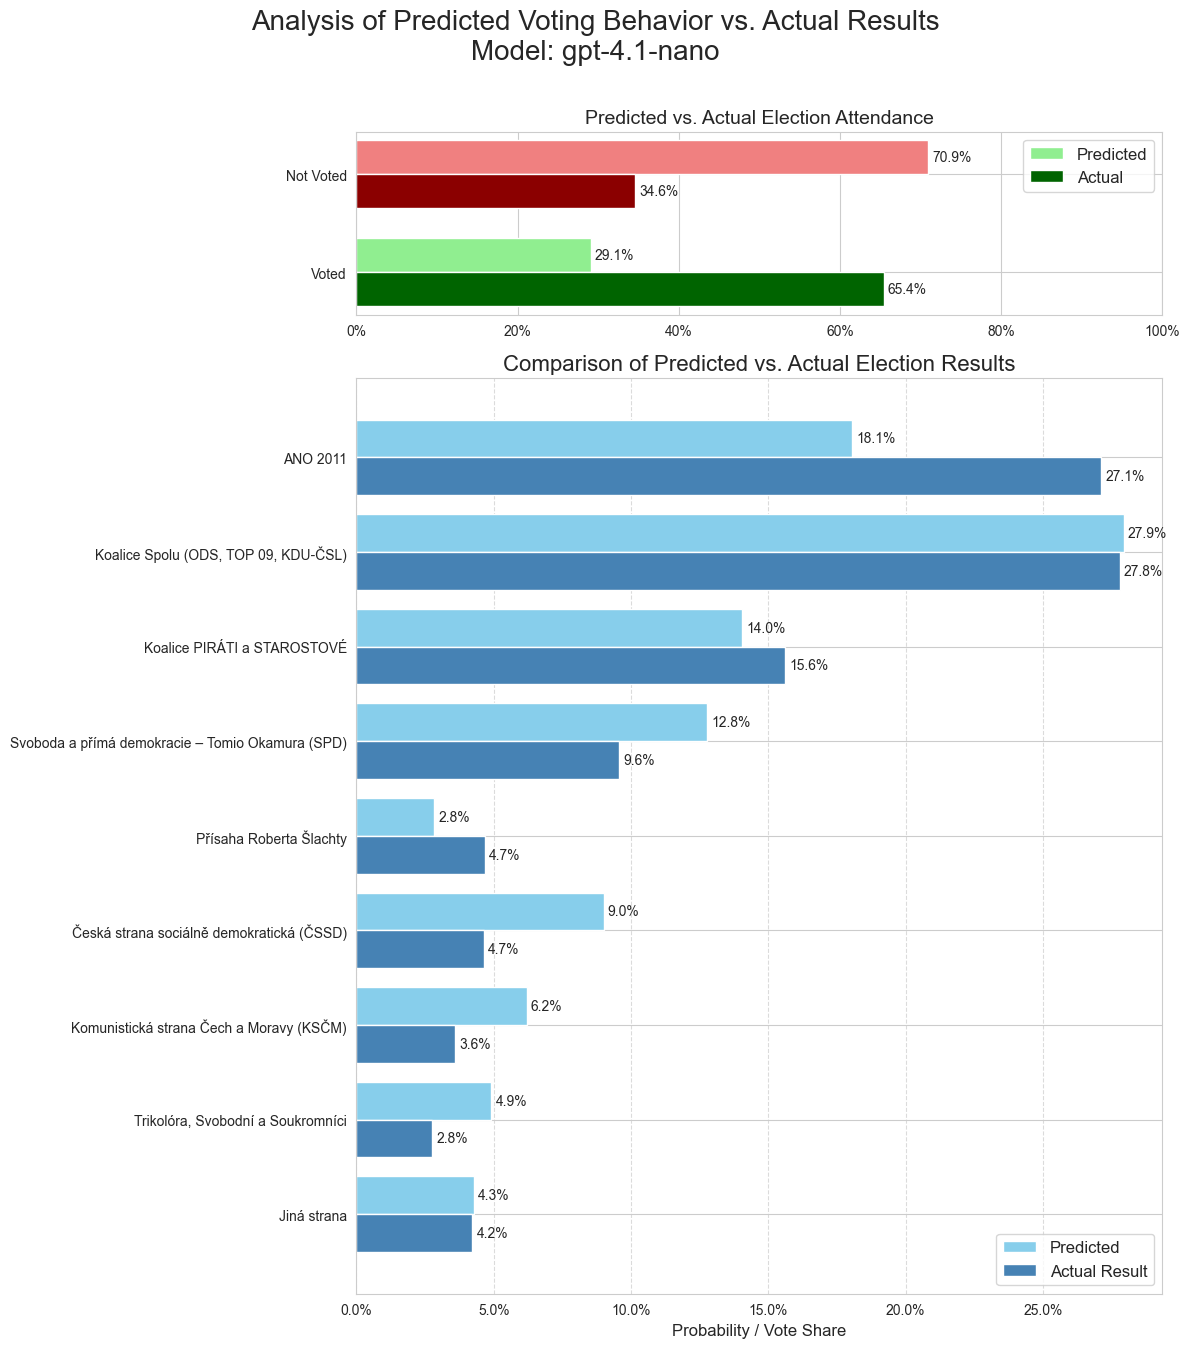

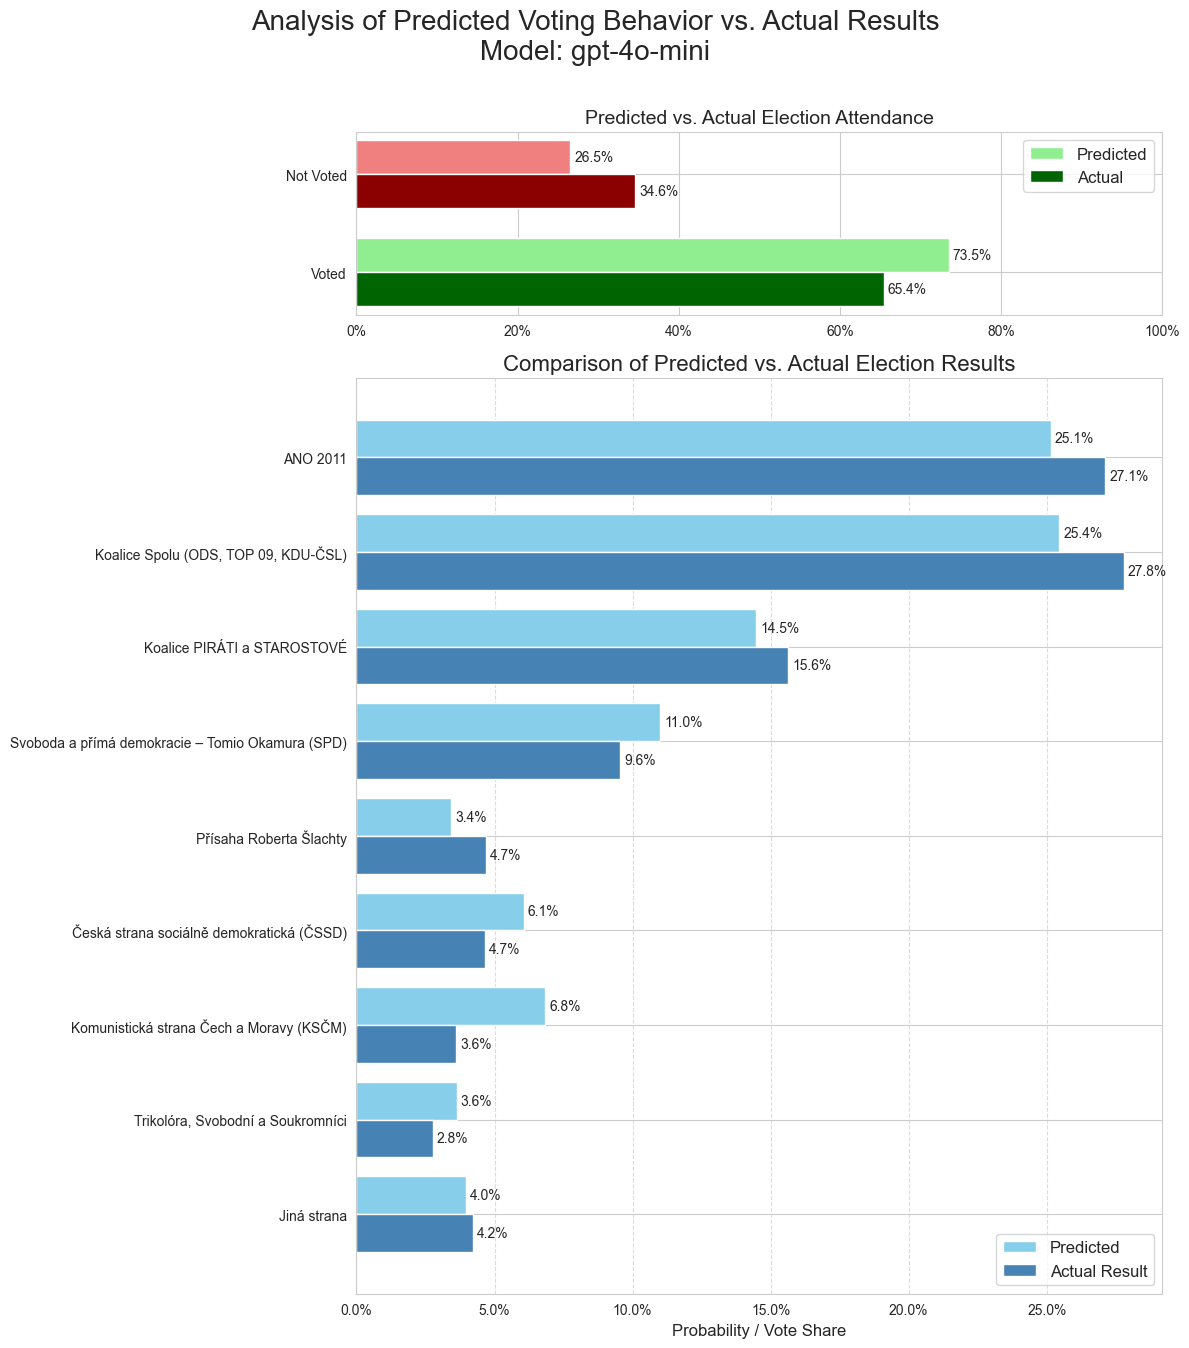

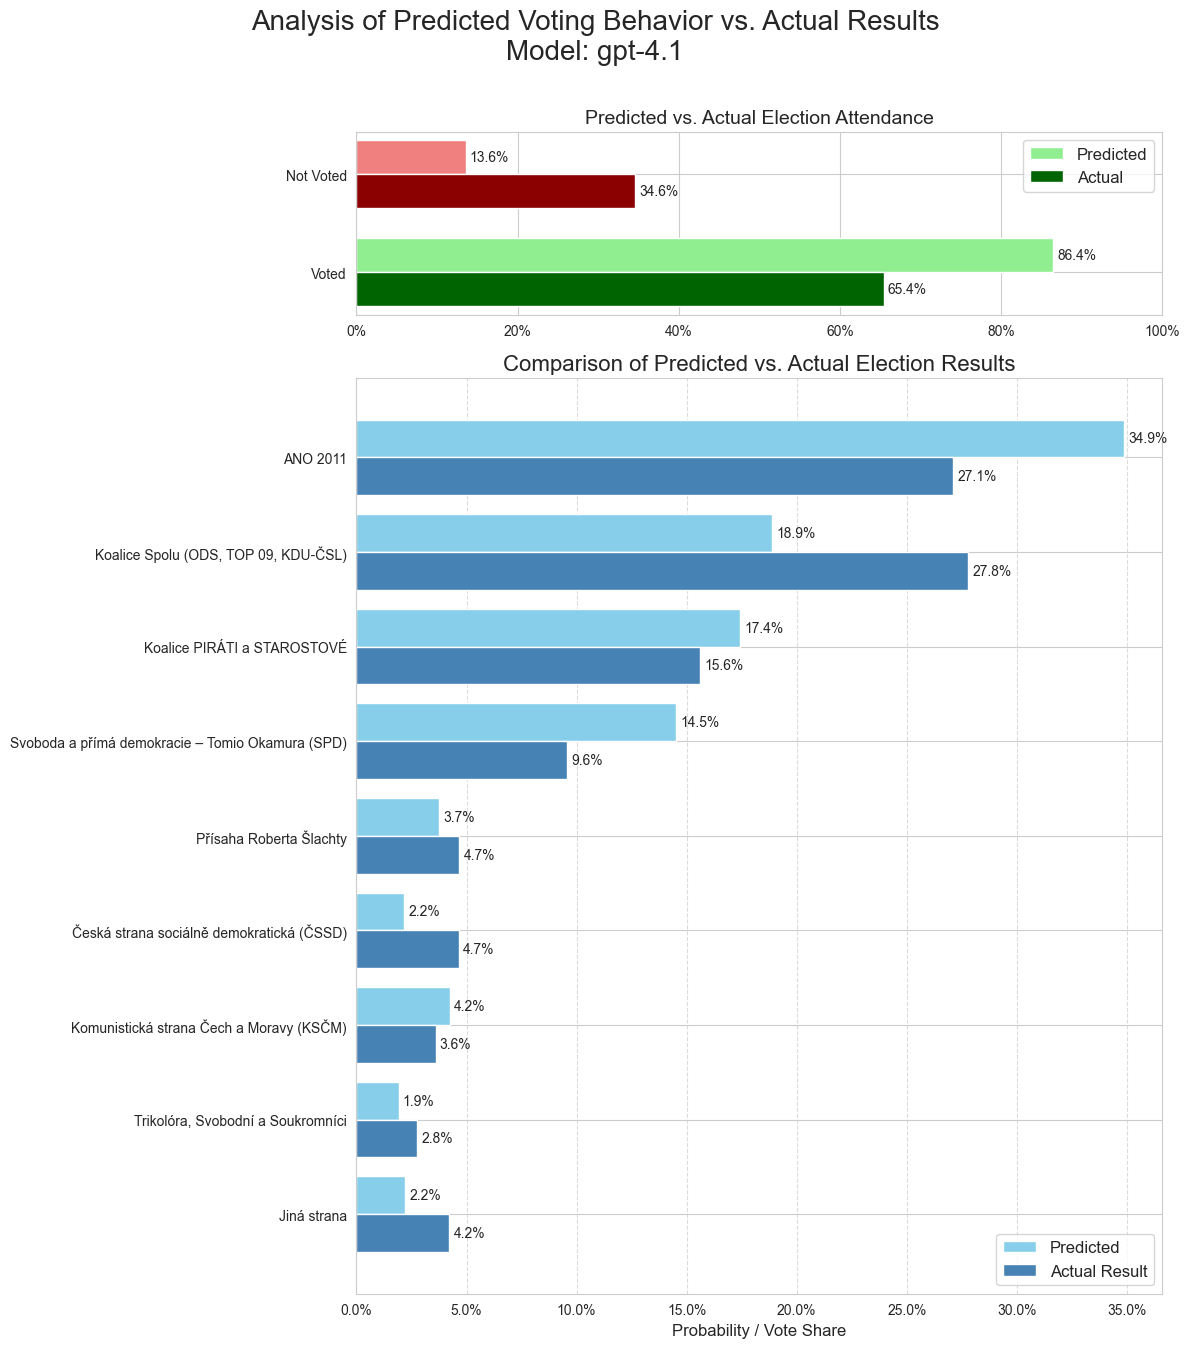

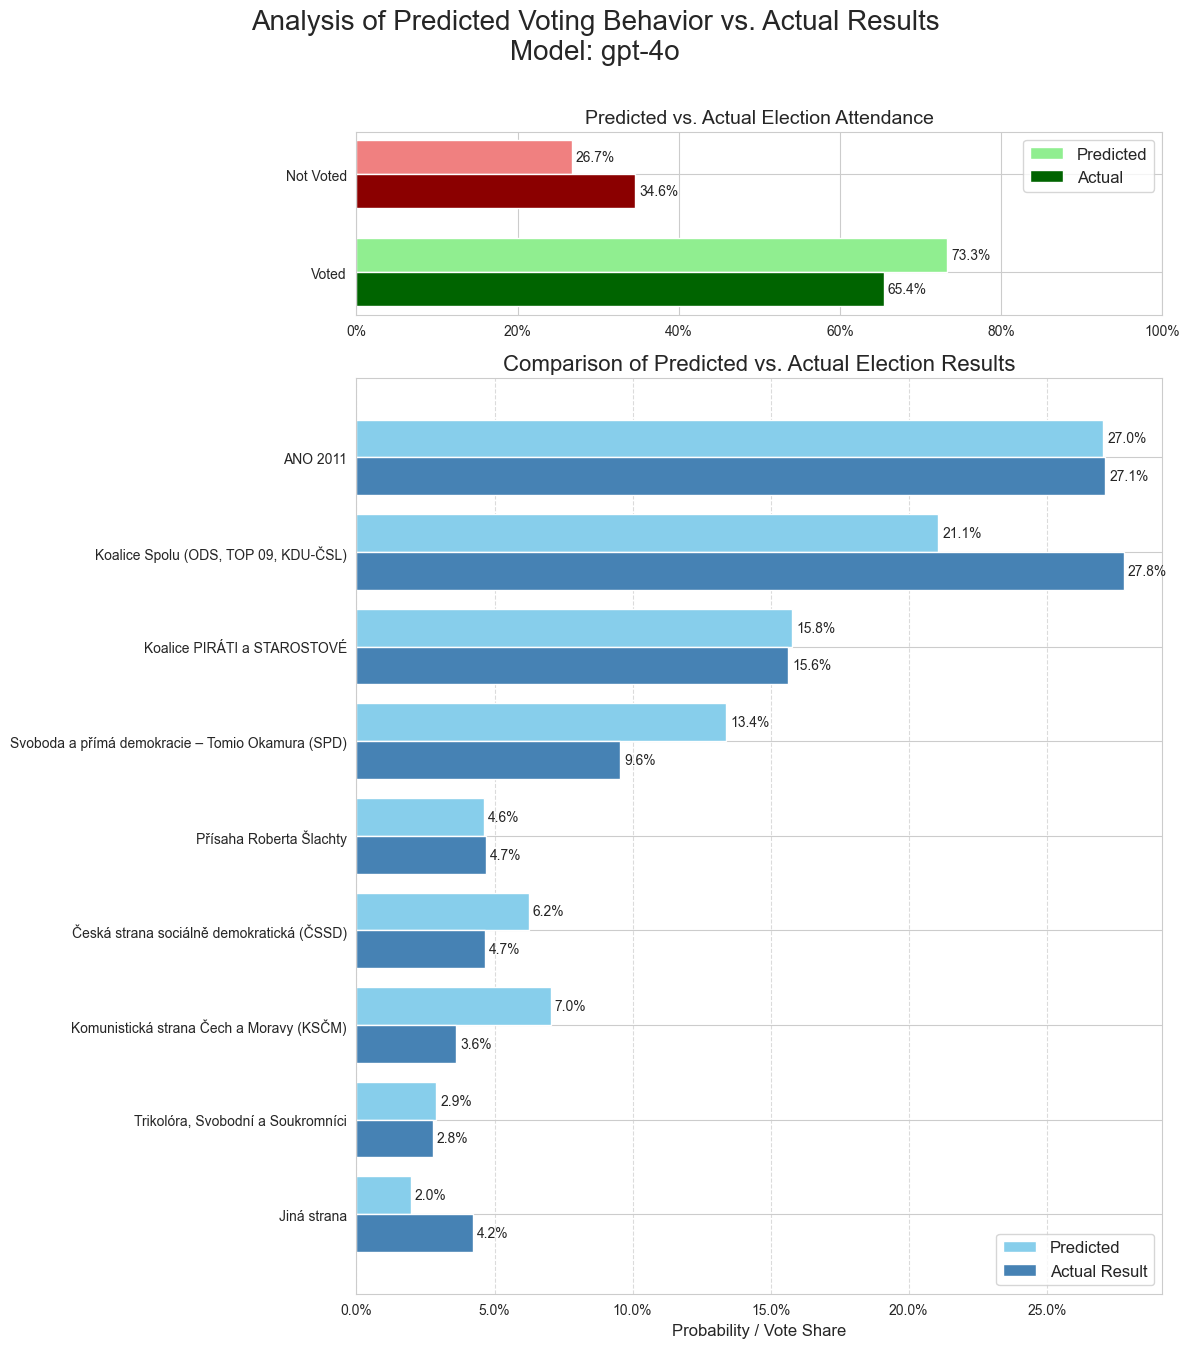

In [13]:
# Generate and save comparison graphs
for model_name, voting_results_df in zip(model_names, voting_results_list):

    predicted_results = Data_Utils.aggregate_results_from_df(voting_results_df)
    fig = Visualization_Utils.visualize_comprehensive_results(
        predicted_results,
        actual_results_country,
        Data_Utils.PARTY_COLUMNS_2021,
        model_name=model_name, actual_is_claimed=False
)
    # Save the plot as a PNG file
    if fig:
        fig.savefig(f"graphs/{model_name}.png")
        print(f"Saved graph for {model_name}")

In [ ]:
# Visualize the matrix with a heatmap
for model_name, voting_results_df in zip(model_names, voting_results_list):

    cov_matrix = voting_results_df[Data_Utils.PARTY_COLUMNS_2021].cov()
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(
        cov_matrix,
        annot=True,       # CRITICAL: Show the numbers in the cells
        cmap='coolwarm',  # A diverging colormap is best to see pos/neg values
        fmt=".4f",        # Format to two decimal places
        linewidths=.5
    )
    plt.title(f'Covariance Matrix \n Model:{model_name}', fontsize=18)
    plt.show()

    cov_matrix.to_csv(f"results/cov_matrix_{model_name}.csv")
    fig.savefig(f"graphs/cov_matrix_{model_name}.png")
    print(f"Saved covariance matrix and graph for {model_name}")

## Region Analysis

In [52]:
MODEL = "gpt-4.1-nano"
# model = "gpt-4o-mini"
# model = "gpt-4.1"
# model = "gpt-4o"

TEMPERATURE = 0
voting_results = pd.read_csv(f"results/voting_results_n=3880_t={TEMPERATURE}_{MODEL}.csv")

region_indices = df.groupby('KRAJ', observed=True).groups

Saved regional MAE CSV to: results/regional_pairwise_mae_t=0_gpt-4.1-nano.csv


,region,Predicted vs Actual,Predicted vs Claimed,Actual vs Claimed
0,Česko,0.028,0.036,0.014
1,Hlavní město Praha,0.046,0.054,0.023
2,Středočeský kraj,0.034,0.050,0.023
3,Jihočeský kraj,0.028,0.034,0.018
4,Plzeňský kraj,0.029,0.036,0.027
5,Karlovarský kraj,0.043,0.049,0.040
6,Ústecký kraj,0.048,0.053,0.013
7,Liberecký kraj,0.039,0.052,0.021
8,Královéhradecký kraj,0.029,0.046,0.038
9,Pardubický kraj,0.026,0.030,0.033


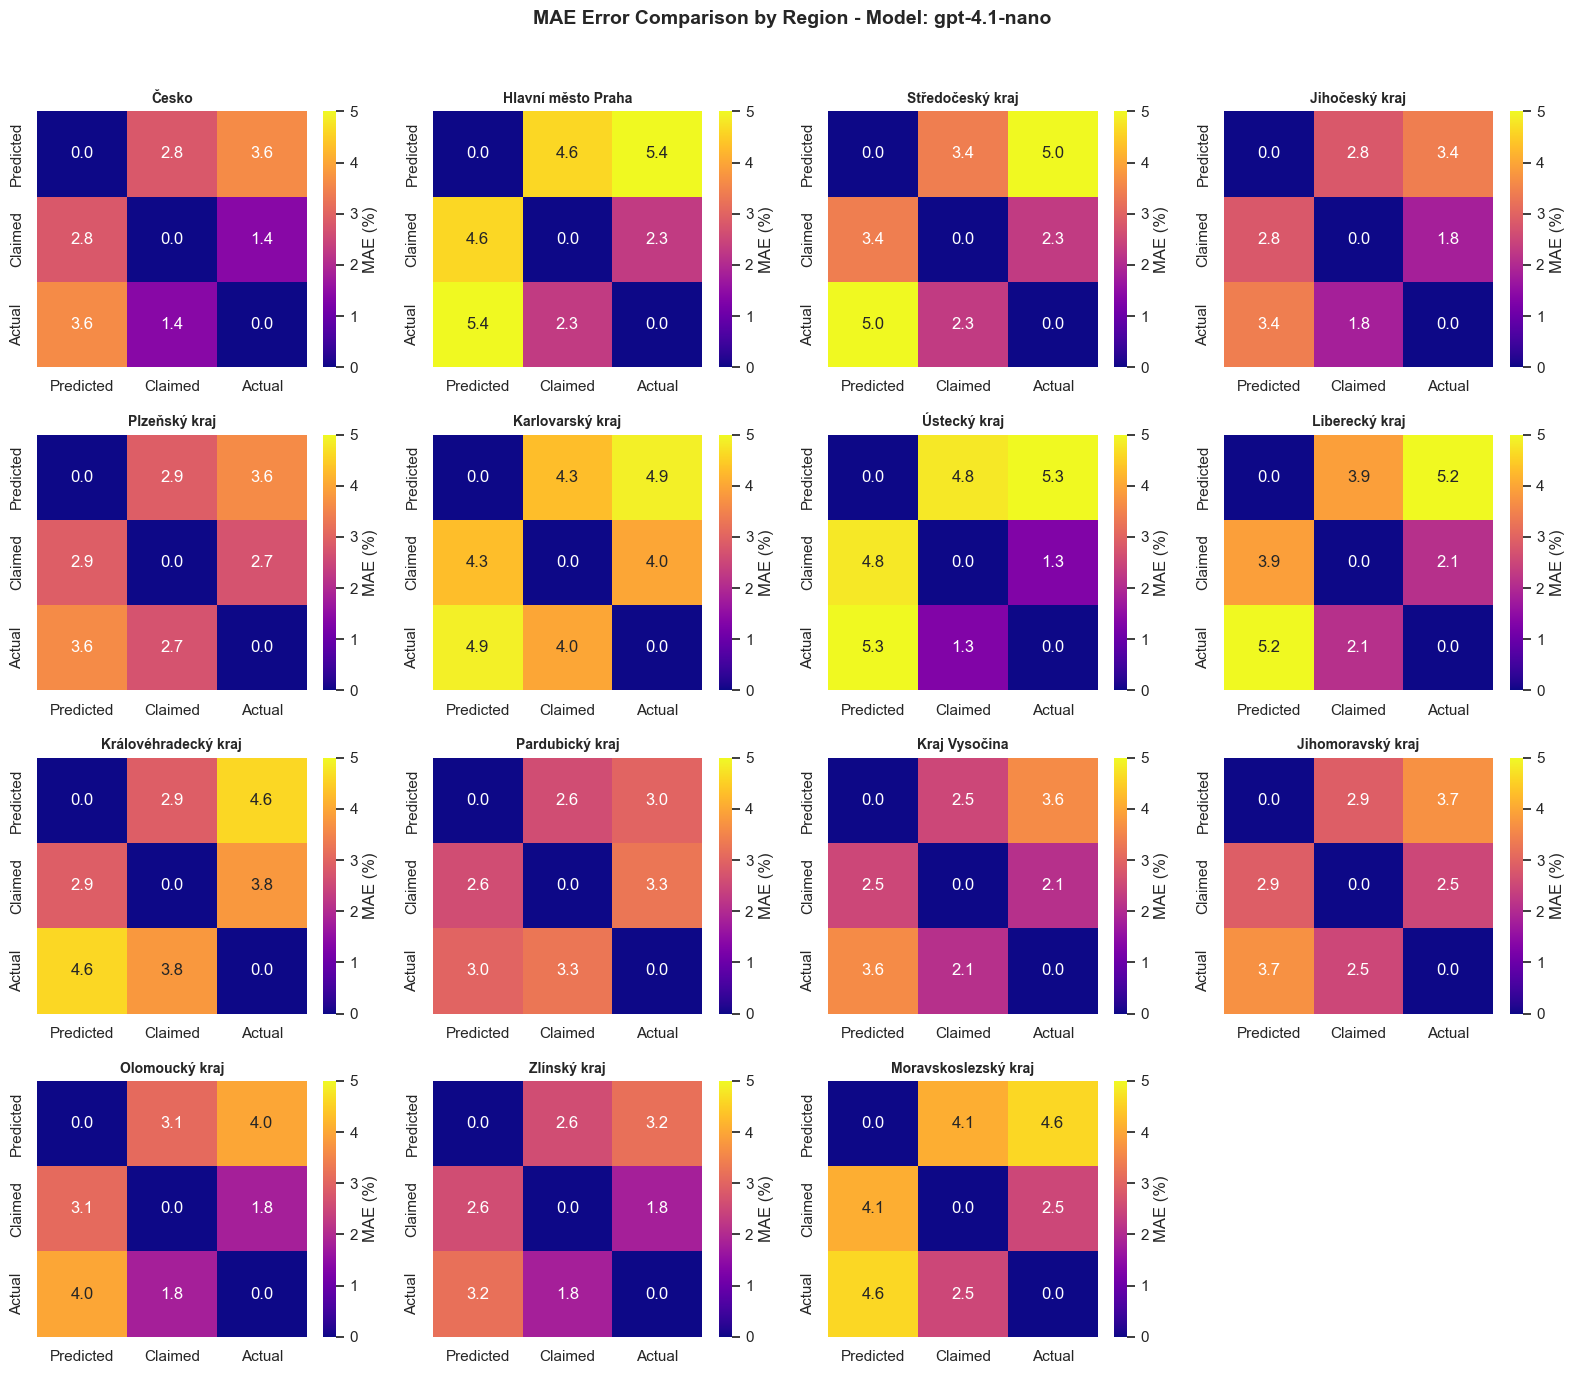

In [53]:
# Generate aggregated results and visualizations
from sklearn.metrics import mean_absolute_error

reload(Data_Utils)

rows = []

for idx, actual_results_region in actual_results_df.iterrows():
    region = actual_results_region["region"]
    if region == 'Česko':
        claimed_votes_region = claimed_votes
        predicted_votes_region = voting_results
    else:
        claimed_votes_region = claimed_votes.iloc[region_indices[region]]
        predicted_votes_region = voting_results.iloc[region_indices[region]]

    claimed_results_region = SoD_Utils.get_actual_results(claimed_votes_region)
    predicted_results_region = Data_Utils.aggregate_results_from_df(predicted_votes_region)

    actual_results_region = actual_results_region[Data_Utils.PARTY_COLUMNS_2021]
    predicted_results_region = predicted_results_region[Data_Utils.PARTY_COLUMNS_2021]
    claimed_results_region = claimed_results_region[Data_Utils.PARTY_COLUMNS_2021]

    mae_pred_vs_clmd = mean_absolute_error(predicted_results_region, claimed_results_region)
    mae_pred_vs_actu = mean_absolute_error(predicted_results_region, actual_results_region)
    mae_actu_vs_clmd = mean_absolute_error(actual_results_region, claimed_results_region)

    rows.append({
        "region": region,
        "Predicted vs Actual": round(mae_pred_vs_actu, 3),
        "Predicted vs Claimed": round(mae_pred_vs_clmd, 3),
        "Actual vs Claimed": round(mae_actu_vs_clmd, 3),
    })

regional_mae_df = pd.DataFrame(rows, columns=[
    "region",
    "Predicted vs Actual",
    "Predicted vs Claimed",
    "Actual vs Claimed",
])

# Ensure results directory exists
os.makedirs("results", exist_ok=True)
# Construct filename with model and temperature for traceability
csv_path = f"results/regional_pairwise_mae_t={TEMPERATURE}_{MODEL}.csv"
regional_mae_df.to_csv(csv_path, index=False)
print(f"Saved regional MAE CSV to: {csv_path}")

fig = Visualization_Utils.visualize_region_errors(regional_mae_df, title=f"MAE Error Comparison by Region - Model: {MODEL}")
fig.savefig(f"graphs/regional_mae_{MODEL}.png")
regional_mae_df

## TODO

In [ ]:
# TODO Covariance of results
# TODO Run with prediction of vote just one party
# TODO Claimed data
# TODO Poslať Data Vitkovi